In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("bengaluru_house_prices.csv")

df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [113]:
print("Shape:", df.shape)

Shape: (13320, 9)


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [115]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [116]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [117]:
df.duplicated().sum()

np.int64(529)

In [118]:
df.dtypes

area_type        object
availability     object
location         object
size             object
society          object
total_sqft       object
bath            float64
balcony         float64
price           float64
dtype: object

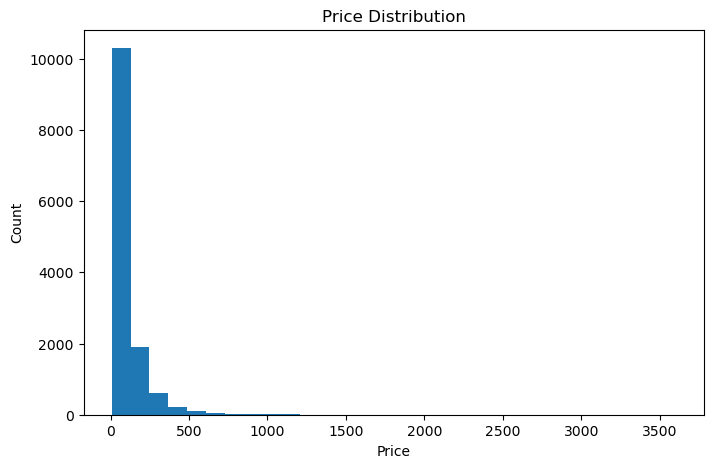

In [119]:
# عرض توزيع أسعار المنازل
plt.figure(figsize=(8, 5))
plt.hist(df['price'], bins=30)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price Distribution")
plt.show()

### Cleaning

In [120]:
df = df.drop_duplicates()

In [121]:
df = df.drop(columns=['society'])

In [122]:
# حذف الصفوف التي تحتوي على missing values قليلة
df = df.dropna(subset=['location', 'size'])

# تعويض القيم الناقصة في الأعمدة الرقمية بالـmedian
df['bath'] = df['bath'].fillna(df['bath'].median())
df['balcony'] = df['balcony'].fillna(df['balcony'].median())

In [123]:
# استخراج عدد غرف النوم من عمود size
df['bhk'] = df['size'].str.extract('(\d+)').astype(int)

# حذف العمود الأصلي
df = df.drop(columns=['size'])

In [124]:
# تحويل total_sqft إلى قيمة رقمية واحدة
def convert_sqft(value):
    try:
        if '-' in str(value):
            values = str(value).split('-')
            return (float(values[0]) + float(values[1])) / 2
        return float(value)
    except:
        return np.nan

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)

In [125]:
# التأكد من نوع البيانات والقيم الناقصة بعد التحويل
print(df['total_sqft'].dtype)
print("Missing total_sqft:", df['total_sqft'].isnull().sum())

float64
Missing total_sqft: 46


In [126]:
# حذف الصفوف التي لا تحتوي على قيمة صحيحة لـ total_sqft
df = df.dropna(subset=['total_sqft'])

In [127]:
# التأكد من عدم وجود missing values
df.isnull().sum()

area_type       0
availability    0
location        0
total_sqft      0
bath            0
balcony         0
price           0
bhk             0
dtype: int64

### Preprocessing

In [128]:
# حذف العمود غير المستخدم في الـmodel
df = df.drop(columns=['availability'])

In [129]:
# تحويل الـcategorical features إلى قيم رقمية
df = pd.get_dummies(
    df,
    columns=['area_type', 'location'],
    drop_first=True
)

In [130]:
# تحويل أعمدة الـboolean فقط إلى أرقام
bool_columns = df.select_dtypes(include='bool').columns
df[bool_columns] = df[bool_columns].astype(int)

In [131]:
from sklearn.preprocessing import MinMaxScaler

# نعمل Scaling لكل البيانات قبل فصل الـfeatures عن الـtarget
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

df_scaled.head()

,total_sqft,bath,balcony,price,bhk,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_ Banaswadi,location_ Basavangudi,...,location_rr nagar,location_sankeswari,location_sapthagiri Layout,location_sarjapura main road,location_singapura paradise,location_t.c palya,location_tc.palya,location_vinayakanagar,"location_white field,kadugodi",location_whitefiled
0,0.020183,0.025641,0.333333,0.008650,0.023810,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.049722,0.102564,1.000000,0.031180,0.071429,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.027530,0.025641,1.000000,0.015033,0.047619,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.029079,0.051282,0.333333,0.024220,0.047619,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.022938,0.025641,0.333333,0.011971,0.023810,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [132]:
# نفصل الـfeatures عن الـtarget بعد الـScaling
X = df_scaled.drop(columns=['price'])
y = df_scaled[['price']]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12728, 1304)
y shape: (12728, 1)


In [133]:
from sklearn.model_selection import train_test_split

# تقسيم البيانات إلى Training و Testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (10182, 1304)
X_test: (2546, 1304)
y_train: (10182, 1)
y_test: (2546, 1)


In [134]:
from tensorflow import keras
from tensorflow.keras import layers

# بناء الـNeural Network
model = keras.Sequential()

# Input layer
model.add(layers.Input(shape=(X_train.shape[1],)))

# Hidden layers
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(16, activation='relu'))

# Output layer مناسب للـRegression
model.add(layers.Dense(1, activation='linear'))

In [135]:
# تجهيز الـmodel للتدريب
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

In [136]:
# عرض شكل الـmodel وعدد الـparameters
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 64)             │        83,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,145 (336.50 KB)

 Trainable params: 86,145 (336.50 KB)

 Non-trainable params: 0 (0.00 B)

In [137]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=40,
    validation_split=0.2
)

Epoch 1/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0015 - mae: 0.0179 - val_loss: 0.0011 - val_mae: 0.0177
Epoch 2/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011 - mae: 0.0141 - val_loss: 8.2127e-04 - val_mae: 0.0133
Epoch 3/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 7.7352e-04 - mae: 0.0121 - val_loss: 8.0214e-04 - val_mae: 0.0136
Epoch 4/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.0668e-04 - mae: 0.0110 - val_loss: 7.0474e-04 - val_mae: 0.0129
Epoch 5/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.1192e-04 - mae: 0.0104 - val_loss: 7.0562e-04 - val_mae: 0.0122
Epoch 6/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.3921e-04 - mae: 0.0100 - val_loss: 7.1224e-04 - val_mae: 0.0119
Epoch 7/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.7493e-04 - mae: 0.0097 - val_loss: 6.6217e-04 - val_mae: 0.0137
Epoch 8/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.3083e-04 - mae: 0.0091 - val_loss: 8.0063e-04 - val_mae: 0.0

In [138]:
test_loss, test_mae = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test MAE:", test_mae)

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.4642e-04 - mae: 0.0098 
Test Loss: 0.0004464163212105632
Test MAE: 0.009801228530704975


In [140]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error

# Scaler خاص بالـ price
target_scaler = MinMaxScaler()
target_scaler.fit(df[['price']])

MinMaxScaler()

In [141]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred_scaled = model.predict(X_test)

# لو عملت scaling للـprice باستخدام target_scaler
y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_test_original = target_scaler.inverse_transform(y_test.values.reshape(-1, 1))

r2 = r2_score(y_test_original, y_pred)
mae = mean_absolute_error(y_test_original, y_pred)

print("Test R²:", r2)
print("Test MAE:", mae)

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Test R²: 0.6631848798615381
Test MAE: 35.20600392059557


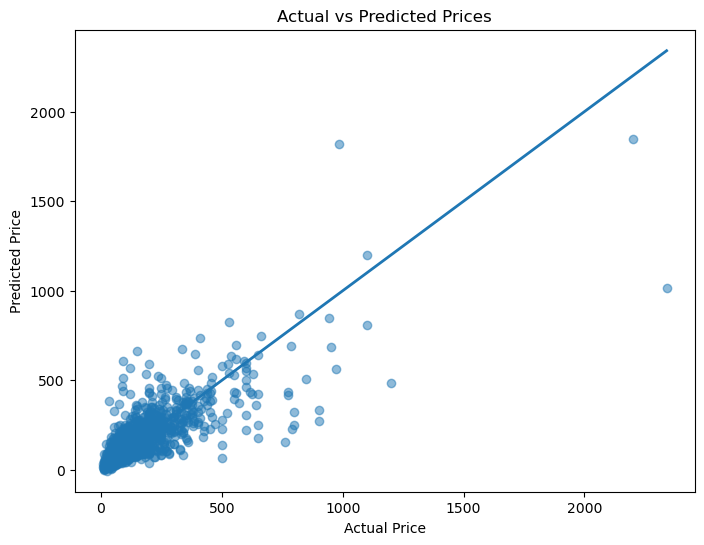

In [142]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test_original, y_pred, alpha=0.5)

plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()